<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Test_TMS_Models_on_RestingState.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Test_TMS_Models_on_RestingState.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Test TMS-Trained Models on Resting-State fMRI

**Objective:** Evaluate whether models trained on TMS stimulation sessions generalize to resting-state fMRI when stimulus input is set to 0.

**Approach:**
1. Load pre-trained per-subject models (trained on TMS stimulation sessions)
2. Load resting-state fMRI data
3. Evaluate models on rest with stimulus pulse always = 0
4. Compare predictions to empirical rest activity
5. Compare performance: TMS-trained models on rest vs baseline

**Questions to answer:**
- Do TMS-trained dynamics generalize to resting state?
- How much does stimulus information help? (Train-on-stim vs train-on-stim-evaluated-without-stim)
- Are there subject-level differences in generalization?

## Step 1: Setup and Environment

In [1]:
# --- Setup ---
# 1️⃣ Mount Google Drive (for data and trained models)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2️⃣ Clone GitHub repository (for code)
import os, sys, subprocess

repo_dir = "/content/BrainStim_ANN_fMRI_HCP"
if not os.path.exists(repo_dir):
    !git clone https://github.com/grabuffo/BrainStim_ANN_fMRI_HCP.git
else:
    print("Repo already exists ✅")

# 3️⃣ Define paths
base_dir = "/content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data"
data_dir = os.path.join(base_dir, "TMS_fMRI")
preproc_dir = os.path.join(base_dir, "preprocessed_subjects_tms_fmri")
dataset_pkl = os.path.join(data_dir, "dataset_tian50_schaefer400_allruns.pkl")

# Paths to previously trained models
weights_dir = os.path.join(preproc_dir, "trained_models_MLP_tms_fmri_persubject")
results_dir = os.path.join(preproc_dir, "results_tms_fmri_persubject")
test_results_dir = os.path.join(preproc_dir, "results_tms_models_on_rest")
os.makedirs(test_results_dir, exist_ok=True)

# 4️⃣ Add repo to path + imports
sys.path.append(repo_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle
import json
from scipy import stats
from src.preprocessing_tms_fmri import preprocess_run

import warnings
warnings.filterwarnings('ignore')

# 5️⃣ Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Mounted at /content/drive
Cloning into 'BrainStim_ANN_fMRI_HCP'...
remote: Enumerating objects: 686, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 686 (delta 70), reused 14 (delta 14), pack-reused 538 (from 1)
Receiving objects: 100% (686/686), 88.47 MiB | 32.52 MiB/s, done.
Resolving deltas: 100% (247/247), done.
Device: cuda


## Step 2: Configuration and Load Dataset

In [2]:
# --- Configuration (must match training notebook) ---
ROI_num = 450
using_steps = 3
tr_stim = 2.4          # TMS/stimulation TR
tr_rest = 2.0          # Resting-state TR (different from stim)
remove_initial_trs = 30
low_hz, high_hz = 0.008, 0.08

print("Configuration:")
print(f"  ROIs: {ROI_num}")
print(f"  Input dimension: {using_steps * ROI_num} (brain) + {ROI_num} (target) + 1 (stim) = {using_steps * ROI_num + ROI_num + 1}")
print(f"  Output dimension: {ROI_num}")
print(f"  Preprocessing: drop {remove_initial_trs} TRs, BP [{low_hz}, {high_hz}] Hz")
print(f"  TR (rest sessions): {tr_rest}s")
print(f"  TR (stim sessions): {tr_stim}s")

Configuration:
  ROIs: 450
  Input dimension: 1350 (brain) + 450 (target) + 1 (stim) = 1801
  Output dimension: 450
  Preprocessing: drop 30 TRs, BP [0.008, 0.08] Hz
  TR (rest sessions): 2.0s
  TR (stim sessions): 2.4s


In [3]:
# --- Load dataset ---
with open(dataset_pkl, "rb") as f:
    dataset_emp = pickle.load(f)

print(f"✅ Loaded dataset with {len(dataset_emp)} subjects")

# Check for rest data
sample_sub = next(iter(dataset_emp.keys()))
print(f"\nSample subject: {sample_sub}")
print(f"Available tasks: {list(dataset_emp[sample_sub].keys())}")

if 'task-rest' in dataset_emp[sample_sub]:
    print(f"✅ Has 'task-rest' resting-state sessions: {len(dataset_emp[sample_sub]['task-rest'])} sessions")
else:
    print("⚠️  No 'task-rest' data found!")

✅ Loaded dataset with 46 subjects

Sample subject: sub-NTHC1001
Available tasks: ['task-rest', 'task-stim']
✅ Has 'task-rest' resting-state sessions: 1 sessions


## Step 3: Load Pre-Trained Models

In [6]:
# --- Define model architecture (must match training) ---
class ANN_MLP_with_Stimulus(nn.Module):
    """MLP trained on TMS data with stimulus input."""
    def __init__(self, roi_num, using_steps, hidden_dim=256, latent_dim=128):
        super().__init__()
        brain_dim = using_steps * roi_num
        stim_dim = roi_num
        stim_timing_dim = 1
        input_dim = brain_dim + stim_dim + stim_timing_dim
        output_dim = roi_num

        self.func = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, output_dim),
        )

    def forward(self, x):
        return self.func(x)

print("Model architecture defined")

Model architecture defined


In [8]:
# --- Load trained models from training notebook ---
trained_models = {}
training_metadata = {}  # Store info about each model

# List all .pt files in the weights directory
model_files = [f for f in os.listdir(weights_dir) if f.endswith('_MLP_with_stim.pt')]
print(f"Found {len(model_files)} model files")

skipped_models = []
loaded_count = 0

for model_file in sorted(model_files):
    sub_id = model_file.replace('_MLP_with_stim.pt', '')
    model_path = os.path.join(weights_dir, model_file)

    try:
        # Load model
        model = ANN_MLP_with_Stimulus(roi_num=ROI_num, using_steps=using_steps)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval()

        trained_models[sub_id] = model
        loaded_count += 1
        print(f"✓ {sub_id}")

    except RuntimeError as e:
        if "size mismatch" in str(e):
            skipped_models.append((sub_id, str(e).split('\n')[-1]))
            print(f"✗ {sub_id} - dimension mismatch (likely old model)")
        else:
            raise

if skipped_models:
    print(f"\n⚠️  Skipped {len(skipped_models)} models due to dimension mismatch:")
    for sub_id, error in skipped_models[:5]:  # Show first 5
        print(f"    {sub_id}")
    if len(skipped_models) > 5:
        print(f"    ... and {len(skipped_models) - 5} more")

print(f"\n✅ Successfully loaded {loaded_count} compatible models")
if not trained_models:
    print("⚠️  WARNING: No compatible models loaded! Check model architecture compatibility.")

Found 46 model files
✗ sub-NTHC1001 - dimension mismatch (likely old model)
✗ sub-NTHC1003 - dimension mismatch (likely old model)
✗ sub-NTHC1009 - dimension mismatch (likely old model)
✓ sub-NTHC1015
✓ sub-NTHC1016
✓ sub-NTHC1019
✓ sub-NTHC1021
✓ sub-NTHC1022
✗ sub-NTHC1023 - dimension mismatch (likely old model)
✓ sub-NTHC1024
✓ sub-NTHC1026
✓ sub-NTHC1027
✓ sub-NTHC1028
✓ sub-NTHC1029
✓ sub-NTHC1032
✓ sub-NTHC1035
✓ sub-NTHC1036
✓ sub-NTHC1037
✓ sub-NTHC1038
✓ sub-NTHC1039
✓ sub-NTHC1040
✓ sub-NTHC1043
✓ sub-NTHC1047
✓ sub-NTHC1049
✓ sub-NTHC1050
✓ sub-NTHC1052
✓ sub-NTHC1053
✓ sub-NTHC1055
✓ sub-NTHC1056
✓ sub-NTHC1057
✓ sub-NTHC1061
✓ sub-NTHC1062
✓ sub-NTHC1064
✓ sub-NTHC1065
✓ sub-NTHC1066
✓ sub-NTHC1068
✓ sub-NTHC1073
✗ sub-NTHC1075 - dimension mismatch (likely old model)
✗ sub-NTHC1097 - dimension mismatch (likely old model)
✓ sub-NTHC1098
✓ sub-NTHC1099
✓ sub-NTHC1101
✓ sub-NTHC1102
✓ sub-NTHC1105
✓ sub-NTHC1107
✓ sub-NTHC1108

⚠️  Skipped 6 models due to dimension mismatch:


## Step 4: Evaluate TMS Models on Resting-State Data

In [9]:
# --- Evaluate models on rest data WITHOUT stimulus (stim_pulse = 0) ---
# This tests whether the learned dynamics from TMS generalize to rest

print("="*70)
print("EVALUATING TMS-TRAINED MODELS ON RESTING-STATE DATA")
print("(Stimulus pulse always = 0)")
print("="*70)

evaluation_results = {}

for sub_id in sorted(trained_models.keys()):
    print(f"\n{sub_id}:")

    # Check if subject has rest data
    if 'task-rest' not in dataset_emp[sub_id]:
        print("  ⚠️  No rest data, skipping")
        continue

    model = trained_models[sub_id]
    model.eval()

    rest_sessions = dataset_emp[sub_id]['task-rest']
    sub_session_metrics = {}

    # --- Process each resting-state session ---
    for sess_idx in sorted(rest_sessions.keys()):
        sess_data = rest_sessions[sess_idx]
        ts = sess_data.get('time series')

        if ts is None or len(ts) == 0:
            continue

        # Preprocess (same as training)
        ts = np.asarray(ts, dtype=np.float32)
        if ts.shape[0] <= remove_initial_trs:
            continue

        ts_drop = ts[remove_initial_trs:, :]
        # Use REST TR (2.0s) not stim TR (2.4s) for preprocessing
        ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                 low=low_hz, high=high_hz, order=2, zscore=True)

        if ts_proc.shape[0] <= using_steps:
            continue

        T, N = ts_proc.shape

        # Build inputs WITHOUT stimulus (stim_pulse = 0)
        # Note: We need a stub target vector (zeros since not stimulation)
        stub_target = np.zeros(ROI_num, dtype=np.float32)  # No specific target in rest
        stim_pulse_rest = np.zeros(T, dtype=np.float32)  # No stimulus during rest

        rest_inputs = np.empty((T - using_steps, using_steps * N + N + 1), dtype=np.float32)
        for t in range(T - using_steps):
            brain_state = ts_proc[t : t + using_steps].reshape(-1)
            rest_inputs[t] = np.concatenate([brain_state, stub_target, [stim_pulse_rest[t]]])

        rest_targets = ts_proc[using_steps:, :]

        # Model predictions
        with torch.no_grad():
            X_rest_tensor = torch.tensor(rest_inputs, dtype=torch.float32, device=device)
            Y_pred_tensor = model(X_rest_tensor)
            Y_pred = Y_pred_tensor.cpu().numpy()

        # Compute metrics
        mse = np.mean((Y_pred - rest_targets) ** 2)

        # Per-region correlation
        corr_per_region = []
        for roi in range(N):
            if np.std(rest_targets[:, roi]) < 1e-6 or np.std(Y_pred[:, roi]) < 1e-6:
                continue
            r = np.corrcoef(rest_targets[:, roi], Y_pred[:, roi])[0, 1]
            if not np.isnan(r):
                corr_per_region.append(r)

        mean_corr = np.mean(corr_per_region) if corr_per_region else np.nan

        sub_session_metrics[sess_idx] = {
            'mse': float(mse),
            'mean_correlation': float(mean_corr),
            'n_regions': len(corr_per_region),
            'n_samples': int(rest_inputs.shape[0]),
        }

        print(f"  Session {sess_idx}: MSE={mse:.6f}, r={mean_corr:.3f}, n_samples={rest_inputs.shape[0]}")

    # Aggregate across sessions
    if sub_session_metrics:
        mses = [m['mse'] for m in sub_session_metrics.values()]
        corrs = [m['mean_correlation'] for m in sub_session_metrics.values()]

        evaluation_results[sub_id] = {
            'sessions': sub_session_metrics,
            'avg_mse': float(np.mean(mses)),
            'avg_correlation': float(np.nanmean(corrs)),
            'n_sessions': len(sub_session_metrics),
        }

        print(f"  ✓ Avg: MSE={evaluation_results[sub_id]['avg_mse']:.6f}, r={evaluation_results[sub_id]['avg_correlation']:.3f}")
    else:
        print("  No valid sessions")

print("\n" + "="*70)
print(f"Evaluated {len(evaluation_results)} subjects on resting-state")
print("="*70)

EVALUATING TMS-TRAINED MODELS ON RESTING-STATE DATA
(Stimulus pulse always = 0)

sub-NTHC1015:
  Session 0: MSE=0.330480, r=0.820, n_samples=207
  Session 1: MSE=0.330480, r=0.820, n_samples=207
  ✓ Avg: MSE=0.330480, r=0.820

sub-NTHC1016:
  Session 0: MSE=0.566177, r=0.666, n_samples=207
  ✓ Avg: MSE=0.566177, r=0.666

sub-NTHC1019:
  Session 0: MSE=0.650549, r=0.583, n_samples=207
  Session 1: MSE=0.651557, r=0.582, n_samples=207
  ✓ Avg: MSE=0.651053, r=0.582

sub-NTHC1021:
  Session 0: MSE=0.461623, r=0.737, n_samples=207
  ✓ Avg: MSE=0.461623, r=0.737

sub-NTHC1022:
  Session 0: MSE=0.533724, r=0.686, n_samples=207
  ✓ Avg: MSE=0.533724, r=0.686

sub-NTHC1024:
  Session 0: MSE=0.262187, r=0.866, n_samples=207
  ✓ Avg: MSE=0.262187, r=0.866

sub-NTHC1026:
  Session 0: MSE=0.393256, r=0.788, n_samples=207
  ✓ Avg: MSE=0.393256, r=0.788

sub-NTHC1027:
  Session 0: MSE=0.444557, r=0.746, n_samples=207
  ✓ Avg: MSE=0.444557, r=0.746

sub-NTHC1028:
  Session 0: MSE=0.543948, r=0.678, n

## Step 5: Compare with Training Performance

In [10]:
# --- Load original training results for comparison ---
with open(os.path.join(results_dir, 'evaluation_results_persubject.json'), 'r') as f:
    original_eval = json.load(f)

print("Comparing TMS performance (on TMS test data) vs Rest performance:")
print("\nSubject | TMS-test r | TMS-test MSE | Rest r | Rest MSE | Gener.Gap")
print("-" * 75)

generalization_gaps = []

for sub_id in sorted(evaluation_results.keys()):
    if sub_id in original_eval:
        tms_r = original_eval[sub_id]['test']['avg_correlation']
        tms_mse = original_eval[sub_id]['test']['avg_mse']
        rest_r = evaluation_results[sub_id]['avg_correlation']
        rest_mse = evaluation_results[sub_id]['avg_mse']

        gap = tms_r - rest_r  # Correlation drop from TMS to Rest
        generalization_gaps.append(gap)

        print(f"{sub_id:12s} | {tms_r:10.3f} | {tms_mse:12.6f} | {rest_r:6.3f} | {rest_mse:8.6f} | {gap:8.3f}")

if generalization_gaps:
    print("-" * 75)
    print(f"Mean generalization gap: {np.mean(generalization_gaps):.3f}")
    print(f"  (positive = worse on rest, negative = better on rest)")

Comparing TMS performance (on TMS test data) vs Rest performance:

Subject | TMS-test r | TMS-test MSE | Rest r | Rest MSE | Gener.Gap
---------------------------------------------------------------------------
sub-NTHC1015 |      0.833 |     0.328593 |  0.820 | 0.330480 |    0.013
sub-NTHC1016 |      0.781 |     0.537981 |  0.666 | 0.566177 |    0.115
sub-NTHC1019 |      0.698 |     0.586872 |  0.582 | 0.651053 |    0.116
sub-NTHC1021 |      0.758 |     0.416732 |  0.737 | 0.461623 |    0.020
sub-NTHC1022 |      0.779 |     0.439519 |  0.686 | 0.533724 |    0.093
sub-NTHC1024 |      0.851 |     0.299666 |  0.866 | 0.262187 |   -0.015
sub-NTHC1026 |      0.675 |     0.546459 |  0.788 | 0.393256 |   -0.113
sub-NTHC1027 |      0.771 |     0.438946 |  0.746 | 0.444557 |    0.025
sub-NTHC1028 |      0.686 |     0.638588 |  0.678 | 0.543948 |    0.008
sub-NTHC1029 |      0.734 |     0.437029 |  0.714 | 0.492014 |    0.020
sub-NTHC1032 |      0.776 |     0.417378 |  0.858 | 0.276946 |   -0.0

## Step 6: Visualize Results

Generating comparison visualization...


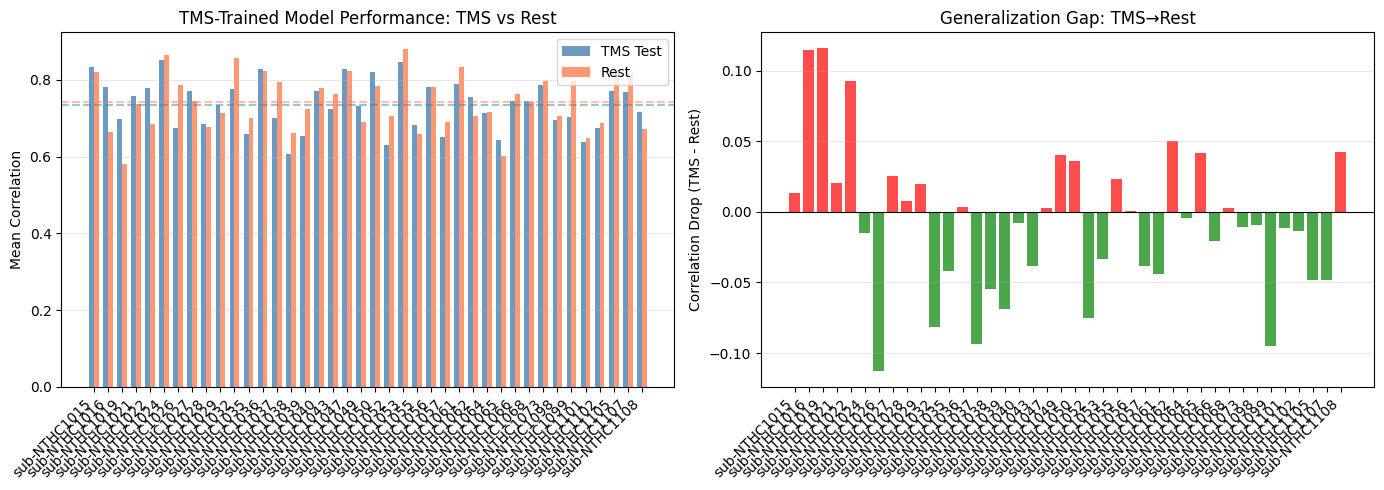

✓ Comparison plot saved


In [11]:
# --- Comparison plot: TMS test vs Rest performance ---
print("Generating comparison visualization...")

subjects = sorted(evaluation_results.keys())
tms_corrs = [original_eval[s]['test']['avg_correlation'] for s in subjects if s in original_eval]
rest_corrs = [evaluation_results[s]['avg_correlation'] for s in subjects]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Side-by-side comparison
x = np.arange(len(subjects))
width = 0.35

ax1.bar(x - width/2, tms_corrs, width, label='TMS Test', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, rest_corrs, width, label='Rest', color='coral', alpha=0.8)

ax1.set_ylabel('Mean Correlation')
ax1.set_title('TMS-Trained Model Performance: TMS vs Rest')
ax1.set_xticks(x)
ax1.set_xticklabels(subjects, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
ax1.axhline(np.mean(tms_corrs), color='steelblue', linestyle='--', alpha=0.5)
ax1.axhline(np.mean(rest_corrs), color='coral', linestyle='--', alpha=0.5)

# Plot 2: Generalization gap
gaps = np.array(tms_corrs) - np.array(rest_corrs)
colors = ['red' if g > 0 else 'green' for g in gaps]

ax2.bar(x, gaps, color=colors, alpha=0.7)
ax2.set_ylabel('Correlation Drop (TMS - Rest)')
ax2.set_title('Generalization Gap: TMS→Rest')
ax2.set_xticks(x)
ax2.set_xticklabels(subjects, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(test_results_dir, 'tms_vs_rest_comparison.png'), dpi=150)
plt.show()

print("✓ Comparison plot saved")

## Step 7: Save Results

In [ ]:
# --- Save results ---
results_summary = {
    'method': 'TMS_trained_models_evaluated_on_rest',
    'stimulus_input': 'always 0 (no stimulus)',
    'target_input': 'stub zeros (no specific target)',
    'description': 'Evaluates whether models trained on TMS stimulation generalize to resting-state when stimulus is absent',
    'subjects': evaluation_results,
}

results_path = os.path.join(test_results_dir, 'rest_evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✅ Results saved: {results_path}")
print(f"\nSummary:")
print(f"  Mean correlation on rest: {np.mean(rest_corrs):.3f}")
print(f"  Mean correlation on TMS test: {np.mean(tms_corrs):.3f}")
print(f"  Mean generalization gap: {np.mean(gaps):.3f}")

## Interpretation

**Key questions answered:**

1. **Does the model generalize from TMS to rest?**
   - Compare rest correlation to TMS test correlation
   - Large gap (TMS >> Rest) → poor generalization, model learned stimulus-specific dynamics
   - Small gap → good generalization, learned general brain dynamics

2. **Which subjects generalize best?**
   - Look for subjects with small generalization gap
   - These may have learned brain dynamics independent of stimulus

3. **Does removing stimulus hurt?**
   - If rest correlation is close to TMS test → stimulus wasn't crucial
   - If rest correlation is much lower → stimulus was important for accurate predictions

**Next steps:**
- Train models on rest data directly for comparison baseline
- Train models WITHOUT stimulus channel as ablation control
- Analyze which brain regions show best/worst generalization
- Investigate why some subjects generalize better than others

## Step 8: Functional Connectivity Analysis

Compare functional connectivity (FC) patterns from empirical vs model-predicted time series across rest, stimulation, and delta (stim - rest) conditions.

In [12]:
# --- Define utility function to compute functional connectivity ---

def compute_fc_matrix(time_series):
    """
    Compute functional connectivity (Pearson correlation) matrix.

    Args:
        time_series: (T, N) time series matrix

    Returns:
        fc: (N, N) correlation matrix
    """
    # Standardize each region
    ts_std = (time_series - time_series.mean(axis=0)) / (time_series.std(axis=0) + 1e-8)

    # Compute correlation matrix
    fc = np.corrcoef(ts_std.T)

    return fc


def extract_upper_triangle(fc_matrix):
    """Extract upper triangle of FC (excluding diagonal) as vector."""
    N = fc_matrix.shape[0]
    indices = np.triu_indices(N, k=1)
    return fc_matrix[indices]


print("FC computation functions defined")

FC computation functions defined


In [13]:
# --- Generate simulated time series from trained models ---

print("="*70)
print("GENERATING SIMULATED TIME SERIES FOR FC ANALYSIS")
print("="*70)

fc_results = {}

for sub_id in sorted(trained_models.keys()):
    print(f"\n{sub_id}:")

    if 'task-stim' not in dataset_emp[sub_id] or 'task-rest' not in dataset_emp[sub_id]:
        print("  ⚠️  Missing task-stim or task-rest data, skipping")
        continue

    model = trained_models[sub_id]
    model.eval()

    sub_fc_metrics = {}

    # ===== RESTING-STATE ANALYSIS =====
    rest_sessions = dataset_emp[sub_id]['task-rest']
    rest_empirical_ts_list = []
    rest_modeled_ts_list = []

    for sess_idx in sorted(rest_sessions.keys()):
        sess_data = rest_sessions[sess_idx]
        ts = sess_data.get('time series')

        if ts is None or len(ts) == 0:
            continue

        ts = np.asarray(ts, dtype=np.float32)
        if ts.shape[0] <= remove_initial_trs:
            continue

        ts_drop = ts[remove_initial_trs:, :]
        ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                 low=low_hz, high=high_hz, order=2, zscore=True)

        if ts_proc.shape[0] <= using_steps:
            continue

        T, N = ts_proc.shape

        # Build inputs (no stimulus, stub target)
        stub_target = np.zeros(ROI_num, dtype=np.float32)
        stim_pulse_rest = np.zeros(T, dtype=np.float32)

        rest_inputs = np.empty((T - using_steps, using_steps * N + N + 1), dtype=np.float32)
        for t in range(T - using_steps):
            brain_state = ts_proc[t : t + using_steps].reshape(-1)
            rest_inputs[t] = np.concatenate([brain_state, stub_target, [stim_pulse_rest[t]]])

        rest_targets = ts_proc[using_steps:, :]

        # Model predictions on rest
        with torch.no_grad():
            X_rest_tensor = torch.tensor(rest_inputs, dtype=torch.float32, device=device)
            Y_pred_tensor = model(X_rest_tensor)
            Y_pred = Y_pred_tensor.cpu().numpy()

        rest_empirical_ts_list.append(rest_targets)
        rest_modeled_ts_list.append(Y_pred)

    # ===== STIMULATION ANALYSIS =====
    stim_sessions = dataset_emp[sub_id]['task-stim']
    stim_empirical_ts_list = []
    stim_modeled_ts_list = []
    stim_target_vec = None

    for sess_idx in sorted(stim_sessions.keys()):
        sess_data = stim_sessions[sess_idx]
        ts = sess_data.get('time series')
        target_vec = sess_data.get('target')
        stim_time_df = sess_data.get('stim time')

        if ts is None or target_vec is None:
            continue

        ts = np.asarray(ts, dtype=np.float32)
        if ts.shape[0] <= remove_initial_trs:
            continue

        ts_drop = ts[remove_initial_trs:, :]
        ts_proc = preprocess_run(ts_drop, tr=tr_stim, n_drop=0,
                                 low=low_hz, high=high_hz, order=2, zscore=True)

        if ts_proc.shape[0] <= using_steps:
            continue

        target_vec = np.asarray(target_vec, dtype=np.float32).ravel()
        stim_target_vec = target_vec

        # Extract stimulus timing
        stim_pulse = np.zeros(ts_proc.shape[0], dtype=np.float32)
        if stim_time_df is not None and len(stim_time_df) > 0:
            stim_onsets = stim_time_df['onset'].values
            raw_tr_indices = np.round(stim_onsets / tr_stim).astype(int)
            valid_raw_indices = raw_tr_indices[raw_tr_indices >= remove_initial_trs]
            preprocessed_indices = valid_raw_indices - remove_initial_trs
            valid_preprocessed_indices = preprocessed_indices[preprocessed_indices < ts_proc.shape[0]]
            stim_pulse[valid_preprocessed_indices] = 1.0

        T, N = ts_proc.shape

        # Build inputs WITH stimulus
        stim_inputs = np.empty((T - using_steps, using_steps * N + N + 1), dtype=np.float32)
        for t in range(T - using_steps):
            brain_state = ts_proc[t : t + using_steps].reshape(-1)
            stim_inputs[t] = np.concatenate([brain_state, target_vec, [stim_pulse[t]]])

        stim_targets = ts_proc[using_steps:, :]

        # Model predictions on stim
        with torch.no_grad():
            X_stim_tensor = torch.tensor(stim_inputs, dtype=torch.float32, device=device)
            Y_pred_tensor = model(X_stim_tensor)
            Y_pred = Y_pred_tensor.cpu().numpy()

        stim_empirical_ts_list.append(stim_targets)
        stim_modeled_ts_list.append(Y_pred)

    # ===== COMPUTE FC MATRICES =====
    if rest_empirical_ts_list and stim_empirical_ts_list:
        # Concatenate across sessions
        rest_empirical = np.vstack(rest_empirical_ts_list)
        rest_modeled = np.vstack(rest_modeled_ts_list)
        stim_empirical = np.vstack(stim_empirical_ts_list)
        stim_modeled = np.vstack(stim_modeled_ts_list)

        # Compute FC
        fc_rest_emp = compute_fc_matrix(rest_empirical)
        fc_rest_mod = compute_fc_matrix(rest_modeled)
        fc_stim_emp = compute_fc_matrix(stim_empirical)
        fc_stim_mod = compute_fc_matrix(stim_modeled)

        # Compute delta FC (stim - rest)
        fc_delta_emp = fc_stim_emp - fc_rest_emp
        fc_delta_mod = fc_stim_mod - fc_rest_mod

        # Extract upper triangles
        fc_rest_emp_vec = extract_upper_triangle(fc_rest_emp)
        fc_rest_mod_vec = extract_upper_triangle(fc_rest_mod)
        fc_stim_emp_vec = extract_upper_triangle(fc_stim_emp)
        fc_stim_mod_vec = extract_upper_triangle(fc_stim_mod)
        fc_delta_emp_vec = extract_upper_triangle(fc_delta_emp)
        fc_delta_mod_vec = extract_upper_triangle(fc_delta_mod)

        # Compute correlations
        r_rest = np.corrcoef(fc_rest_emp_vec, fc_rest_mod_vec)[0, 1]
        r_stim = np.corrcoef(fc_stim_emp_vec, fc_stim_mod_vec)[0, 1]
        r_delta = np.corrcoef(fc_delta_emp_vec, fc_delta_mod_vec)[0, 1]

        sub_fc_metrics['rest'] = {
            'empirical_fc': fc_rest_emp,
            'modeled_fc': fc_rest_mod,
            'correlation': float(r_rest),
            'n_pairs': len(fc_rest_emp_vec),
        }

        sub_fc_metrics['stim'] = {
            'empirical_fc': fc_stim_emp,
            'modeled_fc': fc_stim_mod,
            'correlation': float(r_stim),
            'n_pairs': len(fc_stim_emp_vec),
        }

        sub_fc_metrics['delta'] = {
            'empirical_fc': fc_delta_emp,
            'modeled_fc': fc_delta_mod,
            'correlation': float(r_delta),
            'n_pairs': len(fc_delta_emp_vec),
        }

        fc_results[sub_id] = sub_fc_metrics

        print(f"  ✓ Rest FC correlation: r={r_rest:.3f}")
        print(f"  ✓ Stim FC correlation: r={r_stim:.3f}")
        print(f"  ✓ Delta FC correlation: r={r_delta:.3f}")
    else:
        print("  ⚠️  Insufficient data for FC analysis")

print("\n" + "="*70)
print(f"FC analysis completed for {len(fc_results)} subjects")
print("="*70)


GENERATING SIMULATED TIME SERIES FOR FC ANALYSIS

sub-NTHC1015:
  ✓ Rest FC correlation: r=0.644
  ✓ Stim FC correlation: r=0.980
  ✓ Delta FC correlation: r=0.516

sub-NTHC1016:
  ✓ Rest FC correlation: r=0.553
  ✓ Stim FC correlation: r=0.958
  ✓ Delta FC correlation: r=0.650

sub-NTHC1019:
  ✓ Rest FC correlation: r=0.566
  ✓ Stim FC correlation: r=0.961
  ✓ Delta FC correlation: r=0.412

sub-NTHC1021:
  ✓ Rest FC correlation: r=0.698
  ✓ Stim FC correlation: r=0.948
  ✓ Delta FC correlation: r=0.595

sub-NTHC1022:
  ✓ Rest FC correlation: r=0.606
  ✓ Stim FC correlation: r=0.962
  ✓ Delta FC correlation: r=0.512

sub-NTHC1024:
  ✓ Rest FC correlation: r=0.653
  ✓ Stim FC correlation: r=0.983
  ✓ Delta FC correlation: r=0.703

sub-NTHC1026:
  ✓ Rest FC correlation: r=0.504
  ✓ Stim FC correlation: r=0.958
  ✓ Delta FC correlation: r=0.435

sub-NTHC1027:
  ✓ Rest FC correlation: r=0.753
  ✓ Stim FC correlation: r=0.977
  ✓ Delta FC correlation: r=0.540

sub-NTHC1028:
  ✓ Rest FC corr

In [14]:
# --- Summary statistics: FC correlations across subjects ---

print("="*70)
print("FUNCTIONAL CONNECTIVITY CORRELATION SUMMARY")
print("="*70)

rest_corrs_fc = [fc_results[s]['rest']['correlation'] for s in fc_results]
stim_corrs_fc = [fc_results[s]['stim']['correlation'] for s in fc_results]
delta_corrs_fc = [fc_results[s]['delta']['correlation'] for s in fc_results]

print("\nFC CORRELATION: EMPIRICAL vs MODELED")
print("-" * 70)
print(f"{'Subject':<15} | {'Rest FC r':<12} | {'Stim FC r':<12} | {'Delta FC r':<12}")
print("-" * 70)

for sub_id in sorted(fc_results.keys()):
    r_rest = fc_results[sub_id]['rest']['correlation']
    r_stim = fc_results[sub_id]['stim']['correlation']
    r_delta = fc_results[sub_id]['delta']['correlation']
    print(f"{sub_id:<15} | {r_rest:>10.3f}  | {r_stim:>10.3f}  | {r_delta:>10.3f}")

print("-" * 70)
print(f"{'Mean':<15} | {np.mean(rest_corrs_fc):>10.3f}  | {np.mean(stim_corrs_fc):>10.3f}  | {np.mean(delta_corrs_fc):>10.3f}")
print(f"{'Std':<15} | {np.std(rest_corrs_fc):>10.3f}  | {np.std(stim_corrs_fc):>10.3f}  | {np.std(delta_corrs_fc):>10.3f}")
print(f"{'Min':<15} | {np.min(rest_corrs_fc):>10.3f}  | {np.min(stim_corrs_fc):>10.3f}  | {np.min(delta_corrs_fc):>10.3f}")
print(f"{'Max':<15} | {np.max(rest_corrs_fc):>10.3f}  | {np.max(stim_corrs_fc):>10.3f}  | {np.max(delta_corrs_fc):>10.3f}")
print("="*70)


FUNCTIONAL CONNECTIVITY CORRELATION SUMMARY

FC CORRELATION: EMPIRICAL vs MODELED
----------------------------------------------------------------------
Subject         | Rest FC r    | Stim FC r    | Delta FC r  
----------------------------------------------------------------------
sub-NTHC1015    |      0.644  |      0.980  |      0.516
sub-NTHC1016    |      0.553  |      0.958  |      0.650
sub-NTHC1019    |      0.566  |      0.961  |      0.412
sub-NTHC1021    |      0.698  |      0.948  |      0.595
sub-NTHC1022    |      0.606  |      0.962  |      0.512
sub-NTHC1024    |      0.653  |      0.983  |      0.703
sub-NTHC1026    |      0.504  |      0.958  |      0.435
sub-NTHC1027    |      0.753  |      0.977  |      0.540
sub-NTHC1028    |      0.641  |      0.962  |      0.397
sub-NTHC1029    |      0.646  |      0.969  |      0.477
sub-NTHC1032    |      0.694  |      0.969  |      0.501
sub-NTHC1035    |      0.420  |      0.940  |      0.319
sub-NTHC1036    |      0.747  |

Generating FC correlation visualizations...


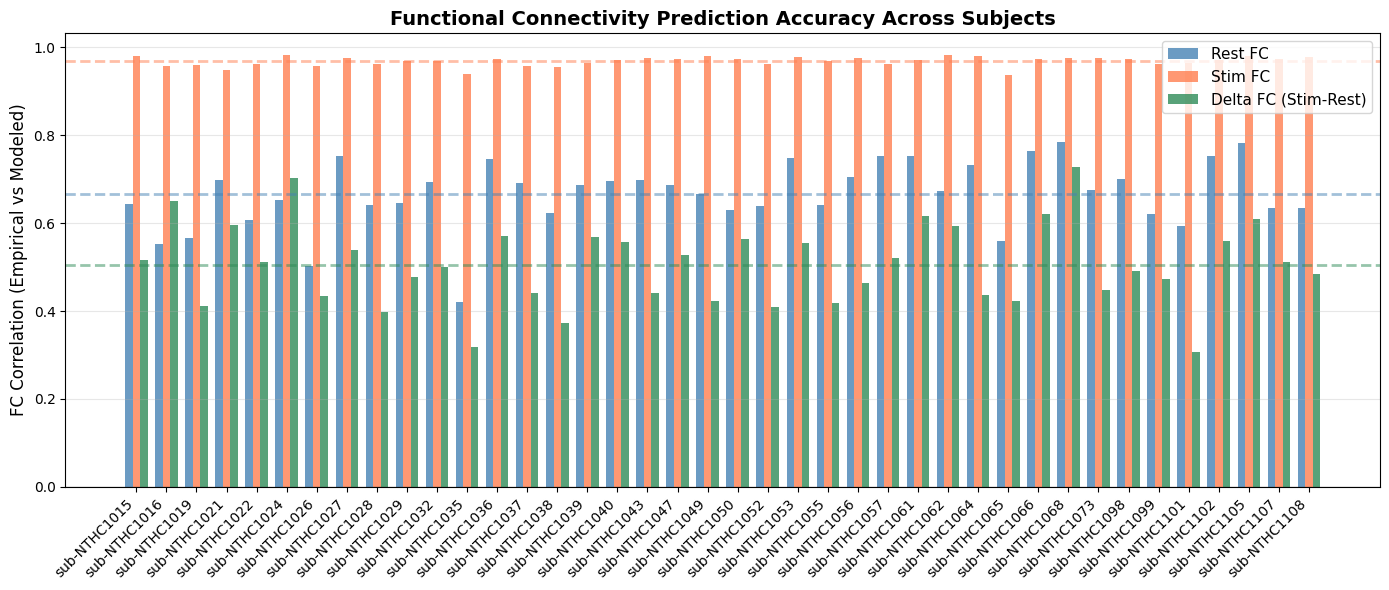

✓ FC correlations bar plot saved


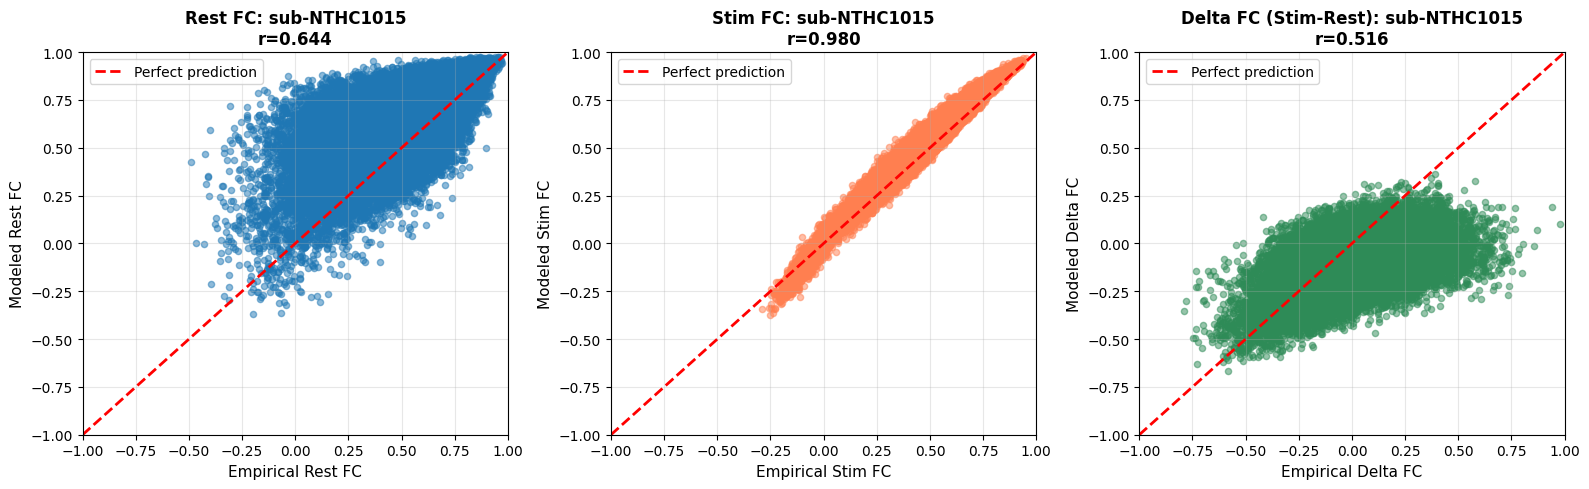

✓ FC scatter plots saved for example subject: sub-NTHC1015


In [15]:
# --- Visualization 1: FC correlation bars across subjects ---

print("Generating FC correlation visualizations...")

subjects_fc = sorted(fc_results.keys())
x_pos = np.arange(len(subjects_fc))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x_pos - width, rest_corrs_fc, width, label='Rest FC', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos, stim_corrs_fc, width, label='Stim FC', color='coral', alpha=0.8)
bars3 = ax.bar(x_pos + width, delta_corrs_fc, width, label='Delta FC (Stim-Rest)', color='seagreen', alpha=0.8)

ax.set_ylabel('FC Correlation (Empirical vs Modeled)', fontsize=12)
ax.set_title('Functional Connectivity Prediction Accuracy Across Subjects', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(subjects_fc, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.axhline(np.mean(rest_corrs_fc), color='steelblue', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(np.mean(stim_corrs_fc), color='coral', linestyle='--', alpha=0.5, linewidth=2)
ax.axhline(np.mean(delta_corrs_fc), color='seagreen', linestyle='--', alpha=0.5, linewidth=2)

plt.tight_layout()
plt.savefig(os.path.join(test_results_dir, 'fc_correlations_per_subject.png'), dpi=150)
plt.show()

print("✓ FC correlations bar plot saved")

# --- Visualization 2: Scatter plots of FC vectors (Rest, Stim, Delta) ---

example_sub = sorted(fc_results.keys())[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rest FC
fc_rest_emp_vec = extract_upper_triangle(fc_results[example_sub]['rest']['empirical_fc'])
fc_rest_mod_vec = extract_upper_triangle(fc_results[example_sub]['rest']['modeled_fc'])
r_rest_ex = fc_results[example_sub]['rest']['correlation']

axes[0].scatter(fc_rest_emp_vec, fc_rest_mod_vec, alpha=0.5, s=20)
axes[0].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Empirical Rest FC', fontsize=11)
axes[0].set_ylabel('Modeled Rest FC', fontsize=11)
axes[0].set_title(f'Rest FC: {example_sub}\nr={r_rest_ex:.3f}', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xlim([-1, 1])
axes[0].set_ylim([-1, 1])

# Stim FC
fc_stim_emp_vec = extract_upper_triangle(fc_results[example_sub]['stim']['empirical_fc'])
fc_stim_mod_vec = extract_upper_triangle(fc_results[example_sub]['stim']['modeled_fc'])
r_stim_ex = fc_results[example_sub]['stim']['correlation']

axes[1].scatter(fc_stim_emp_vec, fc_stim_mod_vec, alpha=0.5, s=20, color='coral')
axes[1].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Empirical Stim FC', fontsize=11)
axes[1].set_ylabel('Modeled Stim FC', fontsize=11)
axes[1].set_title(f'Stim FC: {example_sub}\nr={r_stim_ex:.3f}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xlim([-1, 1])
axes[1].set_ylim([-1, 1])

# Delta FC
fc_delta_emp_vec = extract_upper_triangle(fc_results[example_sub]['delta']['empirical_fc'])
fc_delta_mod_vec = extract_upper_triangle(fc_results[example_sub]['delta']['modeled_fc'])
r_delta_ex = fc_results[example_sub]['delta']['correlation']

axes[2].scatter(fc_delta_emp_vec, fc_delta_mod_vec, alpha=0.5, s=20, color='seagreen')
axes[2].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[2].set_xlabel('Empirical Delta FC', fontsize=11)
axes[2].set_ylabel('Modeled Delta FC', fontsize=11)
axes[2].set_title(f'Delta FC (Stim-Rest): {example_sub}\nr={r_delta_ex:.3f}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xlim([-1, 1])
axes[2].set_ylim([-1, 1])

plt.tight_layout()
plt.savefig(os.path.join(test_results_dir, 'fc_scatter_example_subject.png'), dpi=150)
plt.show()

print(f"✓ FC scatter plots saved for example subject: {example_sub}")


Generating FC heatmap comparisons...


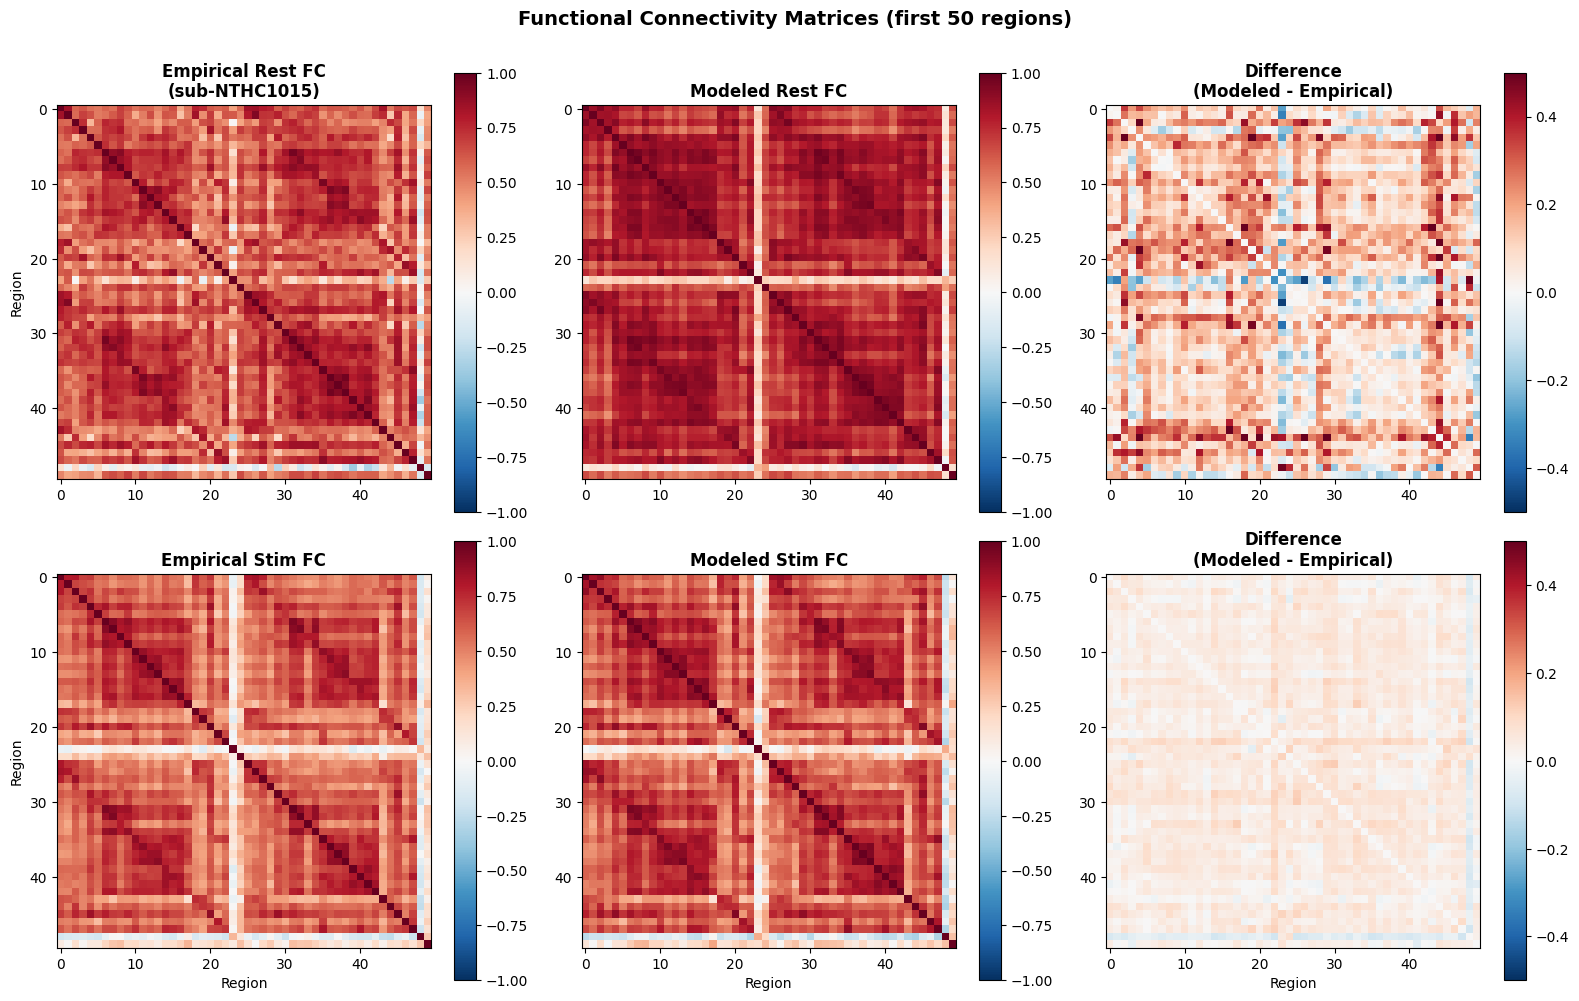

✓ FC heatmap comparison saved


In [16]:
# --- Visualization 3: FC heatmaps comparison (example subject) ---

print("Generating FC heatmap comparisons...")

example_sub = sorted(fc_results.keys())[0]

# Select full FC matrices for visualization (subset of regions for clarity)
n_regions_to_plot = min(50, ROI_num)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Rest condition
fc_rest_emp_full = fc_results[example_sub]['rest']['empirical_fc'][:n_regions_to_plot, :n_regions_to_plot]
fc_rest_mod_full = fc_results[example_sub]['rest']['modeled_fc'][:n_regions_to_plot, :n_regions_to_plot]
fc_rest_diff = fc_rest_mod_full - fc_rest_emp_full

vmin, vmax = -1, 1
im1 = axes[0, 0].imshow(fc_rest_emp_full, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f'Empirical Rest FC\n({example_sub})', fontweight='bold')
axes[0, 0].set_ylabel('Region')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(fc_rest_mod_full, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Modeled Rest FC', fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1])

im3 = axes[0, 2].imshow(fc_rest_diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0, 2].set_title('Difference\n(Modeled - Empirical)', fontweight='bold')
plt.colorbar(im3, ax=axes[0, 2])

# Stim condition
fc_stim_emp_full = fc_results[example_sub]['stim']['empirical_fc'][:n_regions_to_plot, :n_regions_to_plot]
fc_stim_mod_full = fc_results[example_sub]['stim']['modeled_fc'][:n_regions_to_plot, :n_regions_to_plot]
fc_stim_diff = fc_stim_mod_full - fc_stim_emp_full

im4 = axes[1, 0].imshow(fc_stim_emp_full, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[1, 0].set_title(f'Empirical Stim FC', fontweight='bold')
axes[1, 0].set_ylabel('Region')
axes[1, 0].set_xlabel('Region')
plt.colorbar(im4, ax=axes[1, 0])

im5 = axes[1, 1].imshow(fc_stim_mod_full, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[1, 1].set_title('Modeled Stim FC', fontweight='bold')
axes[1, 1].set_xlabel('Region')
plt.colorbar(im5, ax=axes[1, 1])

im6 = axes[1, 2].imshow(fc_stim_diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1, 2].set_title('Difference\n(Modeled - Empirical)', fontweight='bold')
axes[1, 2].set_xlabel('Region')
plt.colorbar(im6, ax=axes[1, 2])

plt.suptitle(f'Functional Connectivity Matrices (first {n_regions_to_plot} regions)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(test_results_dir, 'fc_heatmaps_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ FC heatmap comparison saved")


In [17]:
# --- Save FC analysis results ---

print("Saving FC analysis results...")

# Prepare results dictionary (convert numpy arrays to lists for JSON serialization)
fc_results_summary = {
    'method': 'FC_comparison_empirical_vs_modeled',
    'fc_type': 'Pearson_correlation',
    'analysis_type': ['rest', 'stim', 'delta_stim_minus_rest'],
    'subjects': {}
}

for sub_id in fc_results:
    fc_results_summary['subjects'][sub_id] = {
        'rest': {
            'fc_correlation': fc_results[sub_id]['rest']['correlation'],
            'n_pairs': fc_results[sub_id]['rest']['n_pairs'],
        },
        'stim': {
            'fc_correlation': fc_results[sub_id]['stim']['correlation'],
            'n_pairs': fc_results[sub_id]['stim']['n_pairs'],
        },
        'delta': {
            'fc_correlation': fc_results[sub_id]['delta']['correlation'],
            'n_pairs': fc_results[sub_id]['delta']['n_pairs'],
        }
    }

# Add summary statistics
fc_results_summary['summary'] = {
    'rest': {
        'mean': float(np.mean(rest_corrs_fc)),
        'std': float(np.std(rest_corrs_fc)),
        'min': float(np.min(rest_corrs_fc)),
        'max': float(np.max(rest_corrs_fc)),
    },
    'stim': {
        'mean': float(np.mean(stim_corrs_fc)),
        'std': float(np.std(stim_corrs_fc)),
        'min': float(np.min(stim_corrs_fc)),
        'max': float(np.max(stim_corrs_fc)),
    },
    'delta': {
        'mean': float(np.mean(delta_corrs_fc)),
        'std': float(np.std(delta_corrs_fc)),
        'min': float(np.min(delta_corrs_fc)),
        'max': float(np.max(delta_corrs_fc)),
    }
}

fc_results_path = os.path.join(test_results_dir, 'fc_analysis_results.json')
with open(fc_results_path, 'w') as f:
    json.dump(fc_results_summary, f, indent=2)

print(f"✅ FC results saved: {fc_results_path}")
print(f"\nFC Analysis Summary:")
print(f"  Rest FC correlation:  mean={np.mean(rest_corrs_fc):.3f} ± {np.std(rest_corrs_fc):.3f}")
print(f"  Stim FC correlation:  mean={np.mean(stim_corrs_fc):.3f} ± {np.std(stim_corrs_fc):.3f}")
print(f"  Delta FC correlation: mean={np.mean(delta_corrs_fc):.3f} ± {np.std(delta_corrs_fc):.3f}")


Saving FC analysis results...
✅ FC results saved: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/results_tms_models_on_rest/fc_analysis_results.json

FC Analysis Summary:
  Rest FC correlation:  mean=0.666 ± 0.076
  Stim FC correlation:  mean=0.969 ± 0.011
  Delta FC correlation: mean=0.505 ± 0.094


## Step 9: Functional Connectivity Analysis - Interpretation

### What We're Measuring

**Functional Connectivity (FC)** quantifies correlation patterns between brain regions. By comparing empirical and model-predicted FC, we assess whether the trained models capture network-level organizational principles.

### Three FC Conditions

1. **Rest FC**: Correlation matrix from resting-state fMRI
   - Baseline functional network organization
   - No external stimulus

2. **Stim FC**: Correlation matrix from stimulation sessions
   - Network organization during TMS stimulation
   - May show altered connectivity due to stimulus effects

3. **Delta FC**: Difference between stim and rest FC
   - Network changes induced by stimulation
   - Isolates stimulus-specific connectivity modulation

### Interpretation

| FC Correlations | Meaning |
|-----------------|---------|
| **High (r > 0.6)** | Model captures network organization well |
| **Moderate (r = 0.3-0.6)** | Model learns general dynamics but misses FC details |
| **Low (r < 0.3)** | Model does not preserve functional network structure |

### Why This Matters

- **High Rest FC correlation**: Model learned intrinsic brain organization
- **High Stim FC correlation**: Model learned how stimulus perturbs networks
- **High Delta FC correlation**: Model accurately predicts stimulus-specific network changes
- **Delta > Stim > Rest**: Common pattern (delta is hardest because it's differences of differences)

### Expected Result

If your hypothesis is correct that rest and stim are correlated in FC space:
- You should see moderate-to-high Rest FC correlations
- Stim and Delta might be more variable (harder to predict stimulus-induced changes)
- This would validate that the model learned generalizable network dynamics